<a href="https://colab.research.google.com/github/cocyten27/Curso_CUDA/blob/main/3_5_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

Dataset Loading and Pre-processing

We are using a Credit Card Anomaly detection dataset for its implementation and limit its row count to 40,000 for faster processing. We then standardize the features of the dataset excluding the target variable 'Class' using StandardScaler.

In [ ]:
credit_data = pd.read_csv('creditcard.csv', nrows=40000)
scaler = StandardScaler().fit_transform(credit_data.loc[:,credit_data.columns!='Class'])
scaled_data = scaler[0:40000]
df = pd.DataFrame(data=scaled_data)
X = credit_data.drop(columns=['Class'])
y = credit_data['Class']

Model Making

Now we will define the Isolation Forest model. We calculate the fraction of outliers by looking at the number of fraudulent transactions in the dataset then we create and fit the Isolation Forest model with this outlier fraction.

n_estimators=100: Number of trees in the ensemble (improves accuracy).

contamination: Fraction of outliers in data, helps model set detection threshold.

random_state=42: Ensures reproducible results.

In [ ]:
outlier_fraction = len(credit_data[credit_data['Class']==1])/float(len(credit_data[credit_data['Class']==0]))
model =  IsolationForest(n_estimators=100, contamination=outlier_fraction, random_state=42)
model.fit(df)

IsolationForest(contamination=0.0026067776218167233, random_state=42)

Model Evaluation

Next we will evaluate the model’s performance by calculating its accuracy in detecting anomalies (fraudulent transactions) based on the anomaly scores.

Decision Function: Computes anomaly scores for each point. Prediction Adjustment: Converts predictions (1 = normal, -1 = anomaly) to match dataset labels. Accuracy Calculation: Measures detection rate of anomalies.

In [ ]:
scores_prediction = model.decision_function(df)
y_pred = model.predict(df)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1
print("Accuracy in finding anomaly:",accuracy_score(y,y_pred))

Accuracy in finding anomaly: 0.997175


Comparative Visualization

Now to understand how well the model separates normal and anomalous instances, we will plot the 'Amount' feature to visualize the distinction between normal and fraudulent transactions. We can easily replace 'Amount' with any other feature to visualize its results.

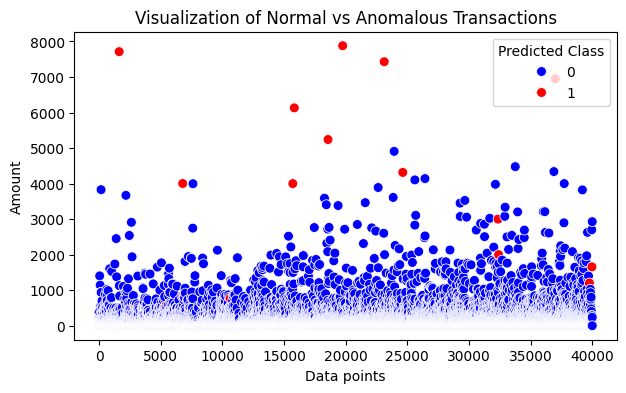

In [ ]:
y_feature = credit_data['Amount']
credit_data['predicted_class'] = y_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=credit_data.index, y=y_feature, hue=credit_data['predicted_class'], palette={0: 'blue', 1: 'red'}, s=50)
plt.title('Visualization of Normal vs Anomalous Transactions')
plt.xlabel('Data points')
plt.ylabel(y_feature.name)
plt.legend(title='Predicted Class', loc='best')
plt.show()